In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

**Data Exploration**

In [114]:
df = pd.read_csv('data/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [116]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [117]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [118]:
df = df.rename(columns={
    'age': "Age",
    'sex': "Sex",
    'cp': "Chest Pain Type",
    'trestbps': "Resting BP",
    'chol': "Cholesterol",
    'fbs': "Fasting Blood Sugar",
    'restecg': "Resting ECG",
    'thalach': "Max Heart Rate",
    'exang': "Exercise Induced Angina",
    'oldpeak': "ST Depression",
    'slope': "ST Slope",
    'ca': "Number of Major Vessels",
    'thal': "Thalassemia Test Results",
    'target': "Heart Disease"
})

In [119]:
for col in df.columns:
    print(f'{col} unique values: {df[col].nunique()}')

Age unique values: 41
Sex unique values: 2
Chest Pain Type unique values: 4
Resting BP unique values: 49
Cholesterol unique values: 152
Fasting Blood Sugar unique values: 2
Resting ECG unique values: 3
Max Heart Rate unique values: 91
Exercise Induced Angina unique values: 2
ST Depression unique values: 40
ST Slope unique values: 3
Number of Major Vessels unique values: 5
Thalassemia Test Results unique values: 4
Heart Disease unique values: 2


In [120]:
df_copy = df.copy()

In [121]:
mappings = {
    'Sex' : {
        0: 'Female',
        1: 'Male',
    },
    'Chest Pain Type' : {
        0: 'Typical angina',
        1: 'Atypical angina',
        2: 'Non-anginal pain',
        3: 'Asymptomatic'
    },
    'Fasting Blood Sugar' : {
        0: 'Less than 120 mg/dl',
        1: 'Greater than 120 mg/dl',
    },
    'Resting ECG' : {
        0: 'Normal',
        1: 'ST-T wave abnormality',
        2: 'Left ventricular hypertrophy'
    },
    'Exercise Induced Angina' : {
        0: 'No',
        1: 'Yes'
    },
    'ST Slope' : {
        0: 'Unsloping',
        1: 'Flat',
        2: 'Downsloping',
    },
    'Thalassemia Test Results' : {
        0: 'Normal',
        1: 'Fixed Defect',
        2: 'Reversible Defect',
        3: 'Unknown'
    },
    'Heart Disease': {
        0: 'No Heart Disease',
        1: 'Heart Disease'
    }
}

In [122]:
for col, mappings in mappings.items():
    df_copy[col] = df_copy[col].map(mappings)

In [123]:
df_copy.head()

,Age,Sex,Chest Pain Type,Resting BP,Cholesterol,Fasting Blood Sugar,Resting ECG,Max Heart Rate,Exercise Induced Angina,ST Depression,ST Slope,Number of Major Vessels,Thalassemia Test Results,Heart Disease
0,52,Male,Typical angina,125,212,Less than 120 mg/dl,ST-T wave abnormality,168,No,1.0,Downsloping,2,Unknown,No Heart Disease
1,53,Male,Typical angina,140,203,Greater than 120 mg/dl,Normal,155,Yes,3.1,Unsloping,0,Unknown,No Heart Disease
2,70,Male,Typical angina,145,174,Less than 120 mg/dl,ST-T wave abnormality,125,Yes,2.6,Unsloping,0,Unknown,No Heart Disease
3,61,Male,Typical angina,148,203,Less than 120 mg/dl,ST-T wave abnormality,161,No,0.0,Downsloping,1,Unknown,No Heart Disease
4,62,Female,Typical angina,138,294,Greater than 120 mg/dl,ST-T wave abnormality,106,No,1.9,Flat,3,Reversible Defect,No Heart Disease


**Analysis & Visualization**

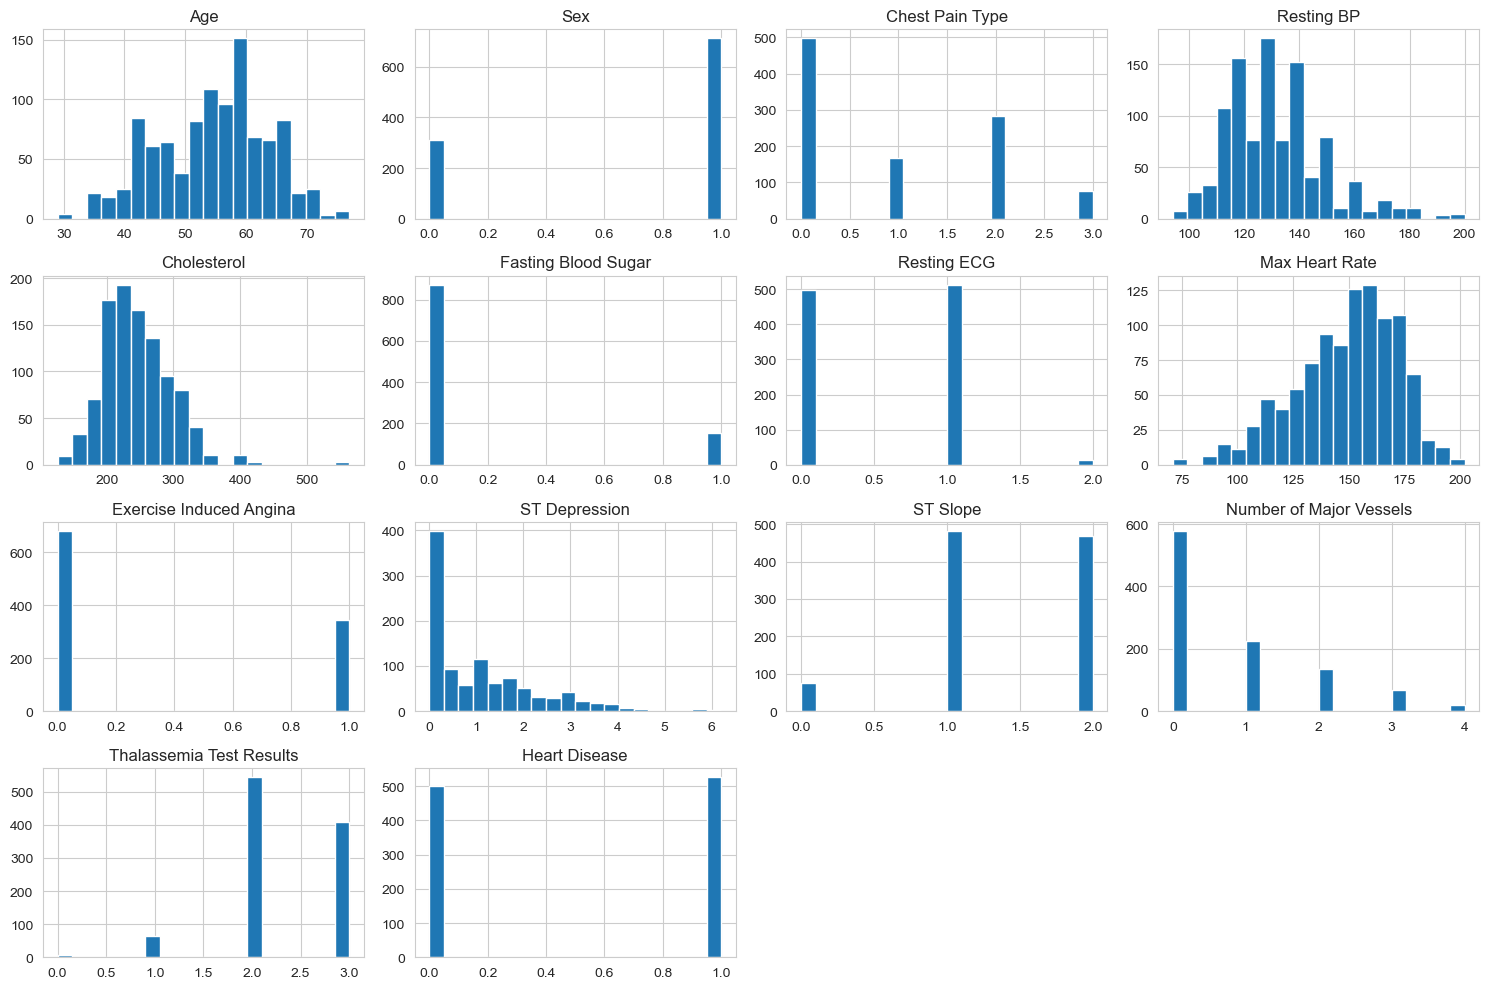

In [124]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()

<Axes: >

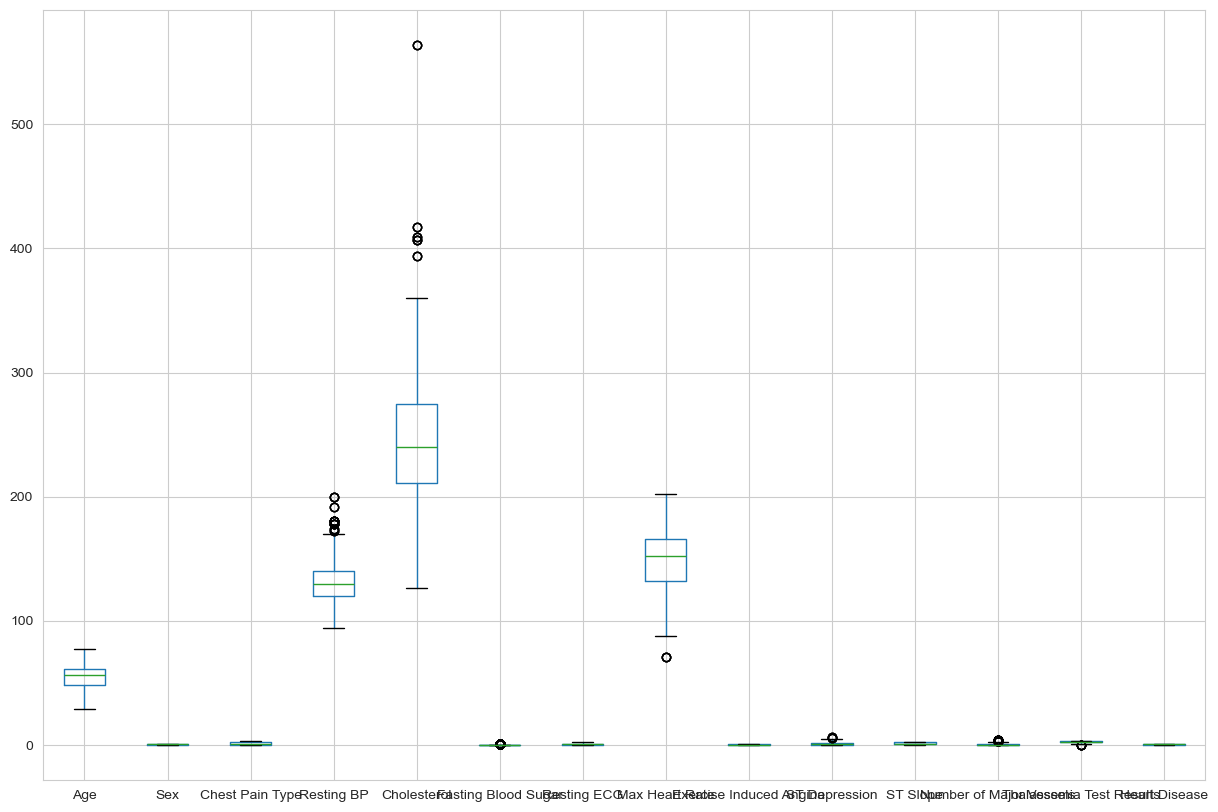

In [125]:
df.boxplot(figsize=(15,10))

In [126]:
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f'{col} has outliers: {outliers.shape[0]} rows')

Age has outliers: 0 rows
Sex has outliers: 0 rows
Chest Pain Type has outliers: 0 rows
Resting BP has outliers: 30 rows
Cholesterol has outliers: 16 rows
Fasting Blood Sugar has outliers: 153 rows
Resting ECG has outliers: 0 rows
Max Heart Rate has outliers: 4 rows
Exercise Induced Angina has outliers: 0 rows
ST Depression has outliers: 7 rows
ST Slope has outliers: 0 rows
Number of Major Vessels has outliers: 87 rows
Thalassemia Test Results has outliers: 7 rows
Heart Disease has outliers: 0 rows


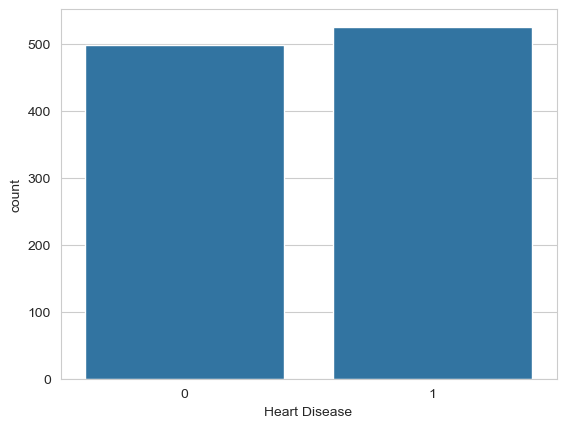

In [127]:
sns.countplot(x='Heart Disease', data=df)
plt.show()

**Heatmap**

---

How strongly each feature is related to every other feature

Each cell contains a correlation value between two variables.
1. +1 → strong positive correlation
2. -1 → strong negative correlation
3. 0 → no linear relationship

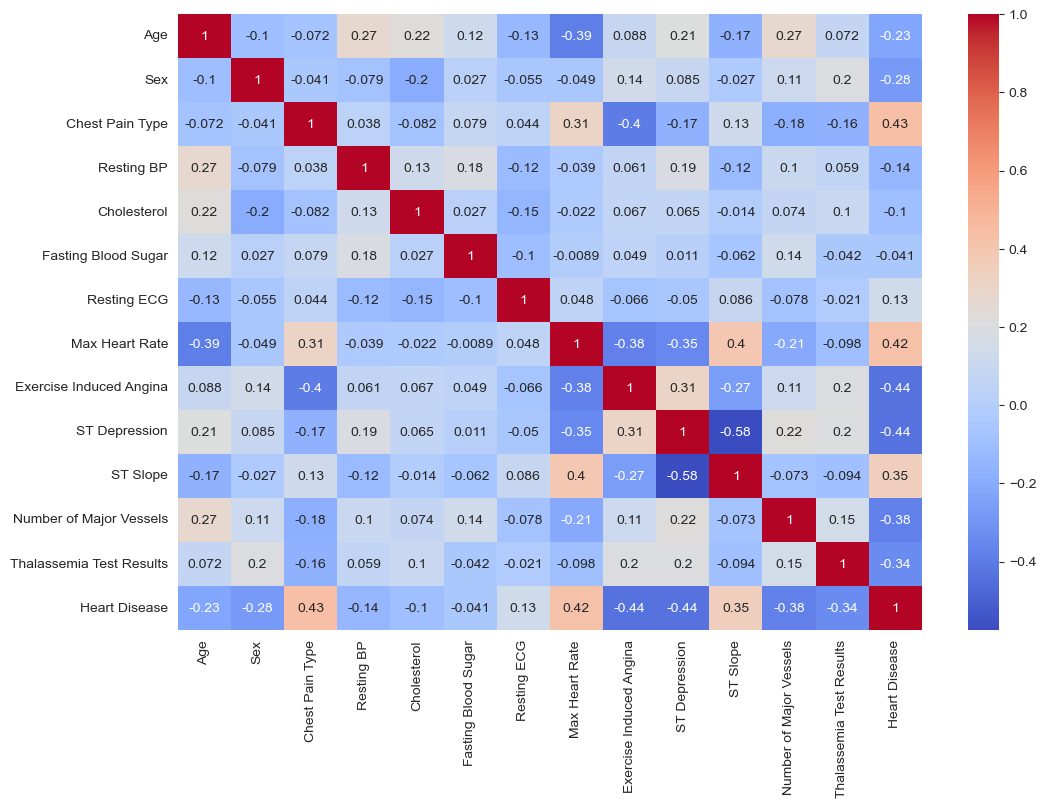

In [128]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

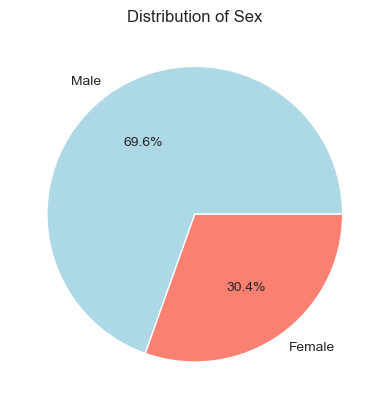

In [129]:
plt.pie(df['Sex'].value_counts(), labels=['Male', 'Female'], autopct="%1.1f%%", colors=['lightblue', 'salmon'])
plt.title("Distribution of Sex")
plt.show()

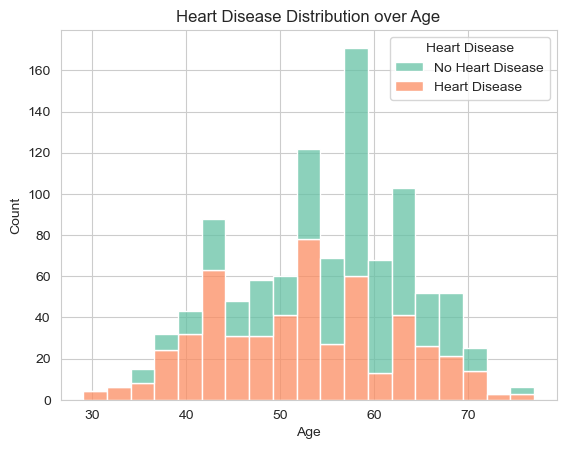

In [130]:
sns.histplot(data=df_copy, x='Age', hue='Heart Disease', multiple='stack', palette='Set2')
plt.title("Heart Disease Distribution over Age")
plt.show()

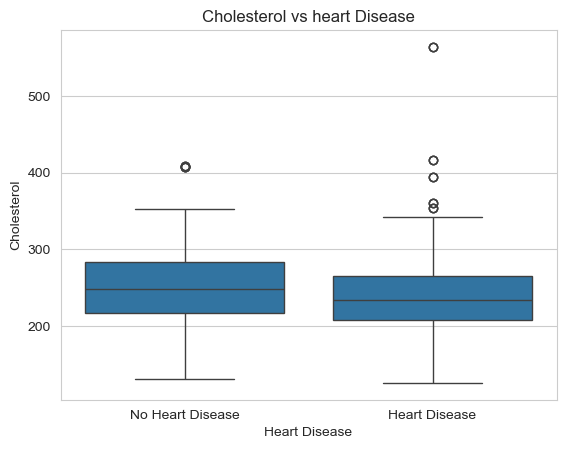

In [131]:
sns.boxplot(x='Heart Disease', y='Cholesterol', data=df_copy)
plt.title('Cholesterol vs heart Disease')
plt.show()

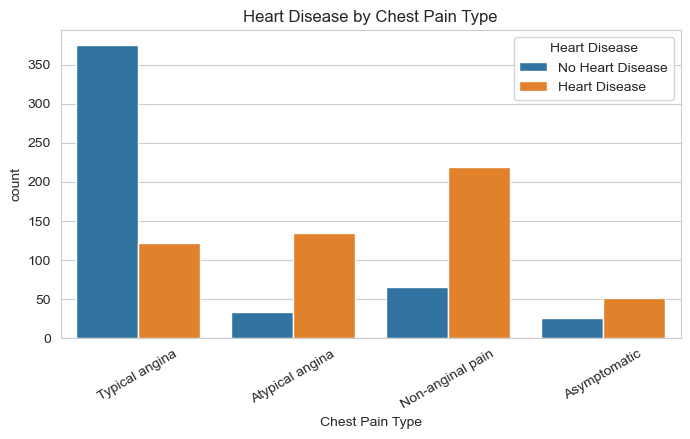

In [132]:
plt.figure(figsize=(8, 4))
sns.countplot(x='Chest Pain Type', data=df_copy, hue='Heart Disease')
plt.xticks(rotation=30)
plt.title('Heart Disease by Chest Pain Type')
plt.show()

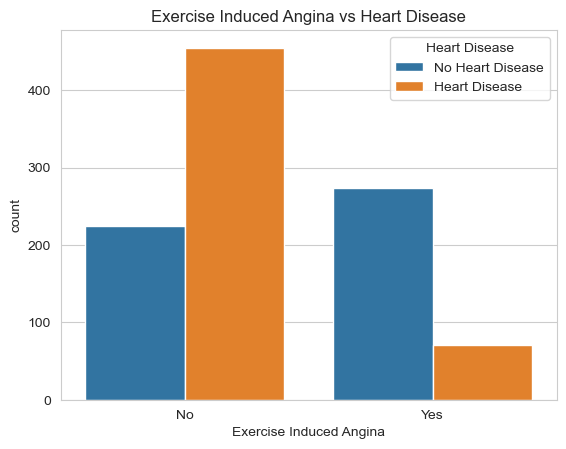

In [133]:
sns.countplot(x='Exercise Induced Angina', hue='Heart Disease', data=df_copy)
plt.title('Exercise Induced Angina vs Heart Disease')
plt.show()

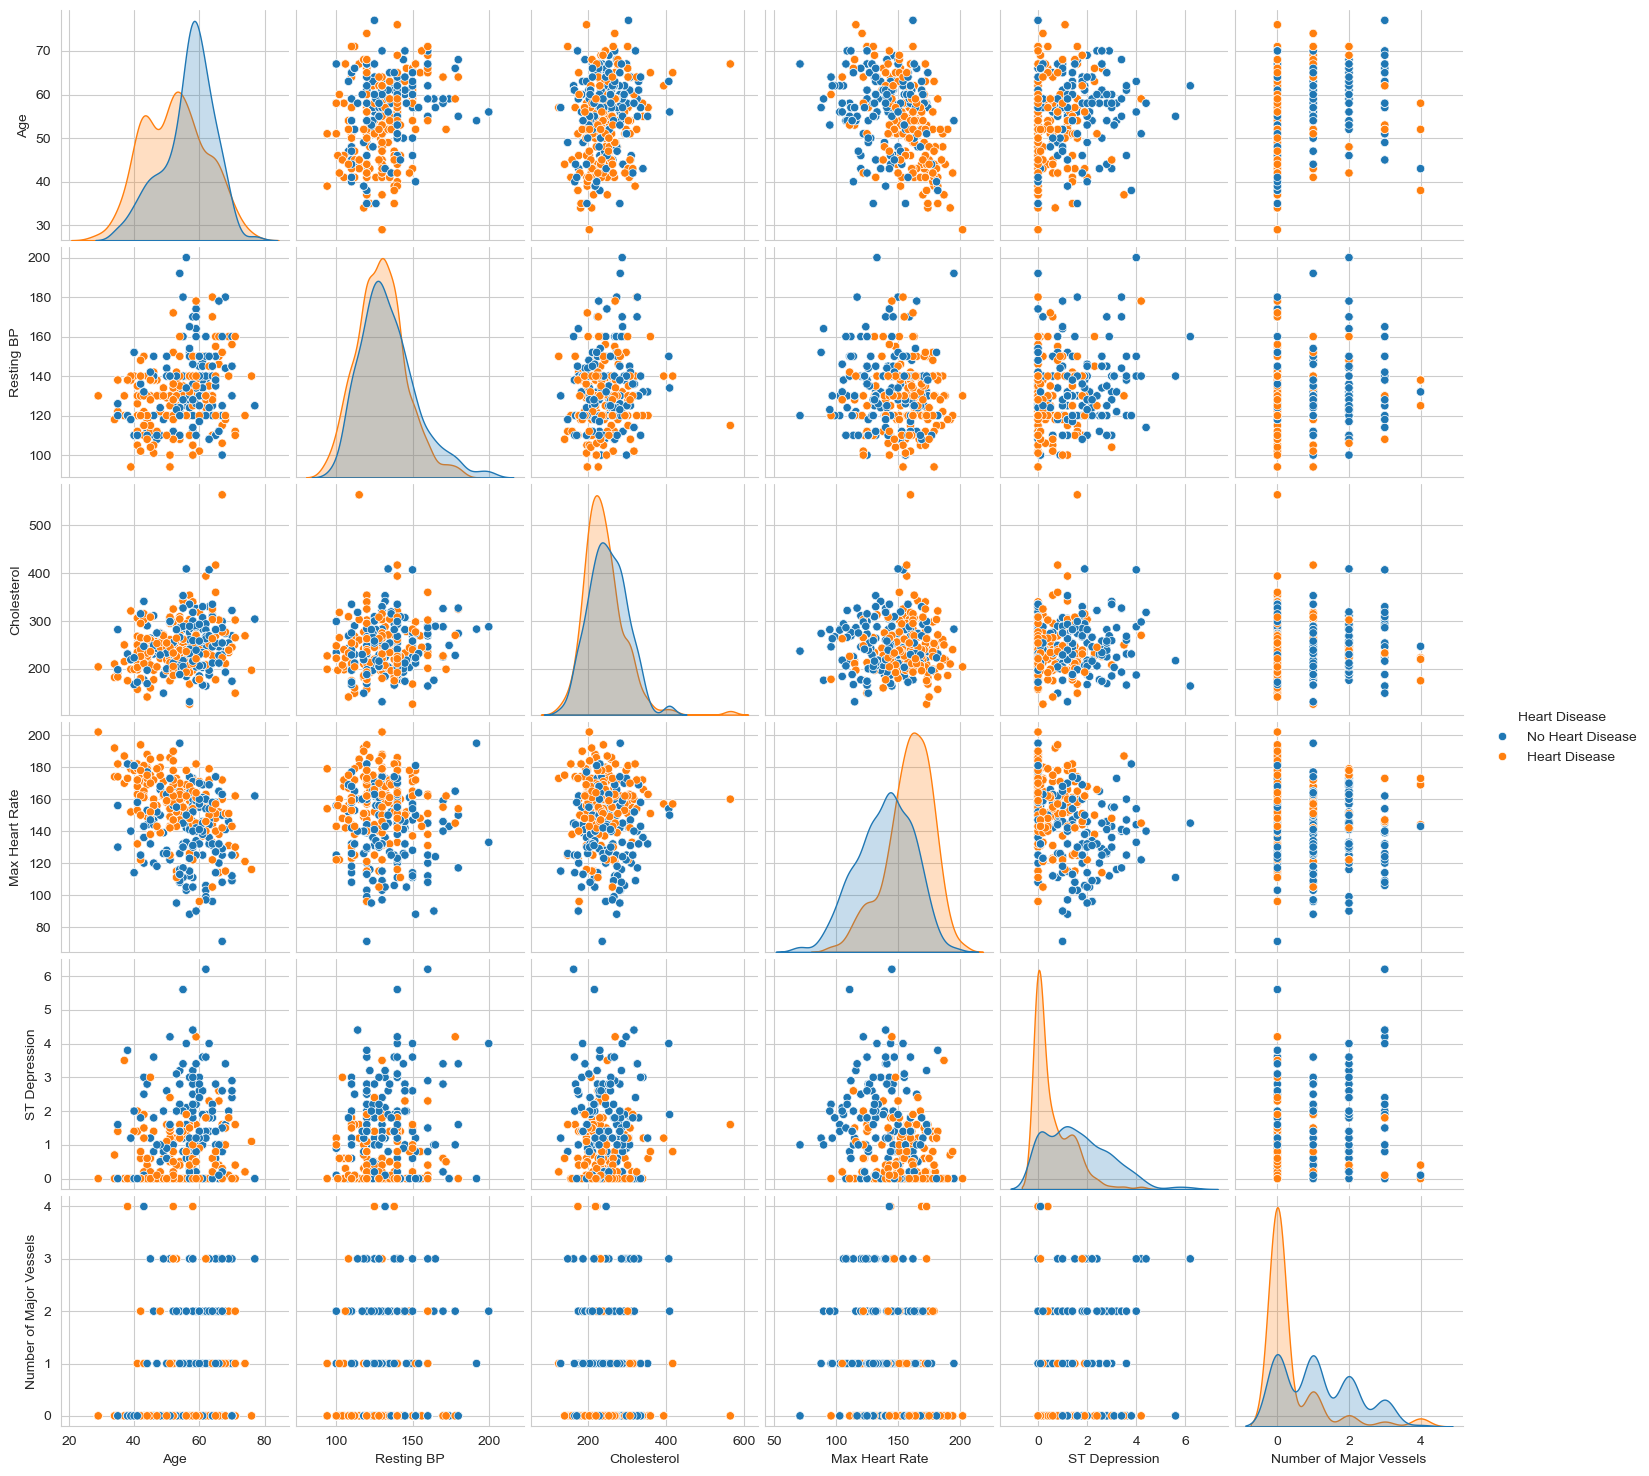

In [134]:
sns.pairplot(df_copy, hue='Heart Disease', diag_kind='kde')
plt.show()

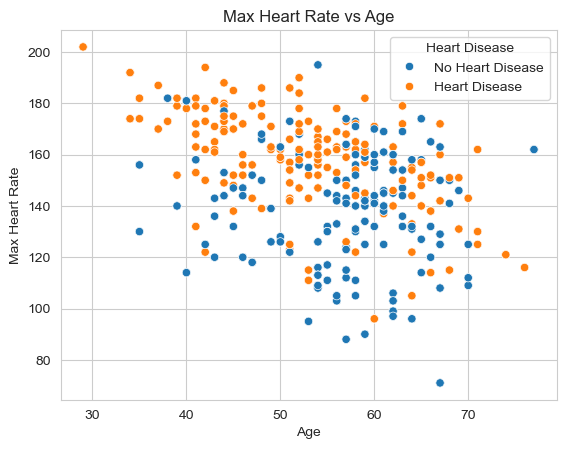

In [135]:
sns.scatterplot(x='Age', y='Max Heart Rate', hue='Heart Disease' ,data=df_copy)
plt.title('Max Heart Rate vs Age')
plt.show()

**Data Preprocessing**

In [136]:
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

In [137]:
X.shape, y.shape

((1025, 13), (1025,))

In [138]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#stratify(y): ensures that "The class distribution remains the same in train and test sets."

In [139]:
scaler = StandardScaler()

In [140]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [141]:
models = {
    "Logistics Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        max_depth=6,
        random_state=42,
    )
}

In [142]:
model_accuracies = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    train_accuracy = model.score(X_train_scaled, y_train)
    test_accuracy = model.score(X_test_scaled, y_test)

    print(f"{name}")
    print(f"\tTrain Accuracy: {train_accuracy:.4f}")
    print(f"\tTest Accuracy: {test_accuracy:.4f}")
    print('----------------------')
    model_accuracies[name] = [train_accuracy, test_accuracy]

Logistics Regression
	Train Accuracy: 0.8463
	Test Accuracy: 0.8098
----------------------
Random Forest
	Train Accuracy: 0.9890
	Test Accuracy: 0.9659
----------------------


In [143]:
model_accuracies = pd.DataFrame(model_accuracies, index=['Test Accuracy', 'Train Accuracy']).T
model_accuracies.sort_values(by='Test Accuracy', ascending=False, inplace=True)

In [144]:
model_accuracies

,Test Accuracy,Train Accuracy
Random Forest,0.989024,0.965854
Logistics Regression,0.846341,0.809756


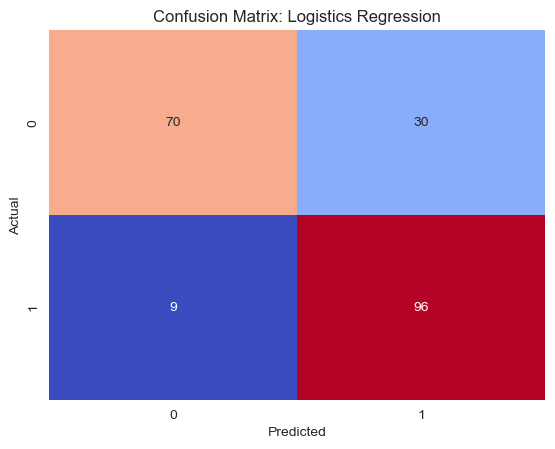

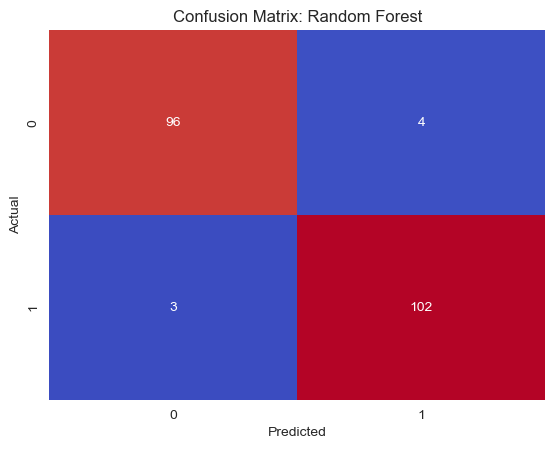

In [145]:
model_performance = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    model_performance[name] = {'Train': train_acc, 'Test': test_acc}

    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="coolwarm", cbar=False)
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()